# Análise de histograma e equalização
## Aula 9

## Histogramas
* Um histograma representa a frequência com que cada valor aparece numa imagem;
* Faz uma distribuição **estatística** de cada valor;
* Com este gráfico, podemos:
  * Ter uma ideia geral quanto a iluminação de uma imagem;
  * Ter uma ideia geral quanto o contraste de uma imagem;
  * Ver picos de saturação;
  * Obter valores para thresholding;
  * Etc.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
girl = np.array(Image.open('girl.jpg'))
(l, c, p) = girl.shape
# usando a fórmula de luminosidade para converter a imagem para tons de cinza
# formula: 0.2126 * R + 0.7152 * G + 0.0722 * B onde 0.
girl_gray = ((0.2126 * girl[:, :, 0]) + (0.7152 * girl[:, :, 1]) + (0.0722 * girl[:, :, 2])).astype(np.uint8)

In [3]:
def histogram_gray(img):
    (l, c) = img.shape
    # Histograma com 1 linha e 256 colunas, preenchido com 0.
    histogram = np.zeros(256, dtype=np.int32)

    # Percorrer cada pixel da imagem.
    for i in range(l):
        for j in range(c):
            # Normalizar intensidade do pixel 
            intensity = img[i, j]
            # Incrementar de 1 a quantidade de pixels no histograma,
            # utilizando a intensidade como índice.
            histogram[intensity] += 1
            
    return histogram

def show_histogram_gray(img):
    histogram = histogram_gray(img)
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    # vmin e vmax não permitem que o matplotlib faça normalização das cores.
    # vmin será o valor mínimo da intensidade (0) e vmax o valor máximo (255).
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram)

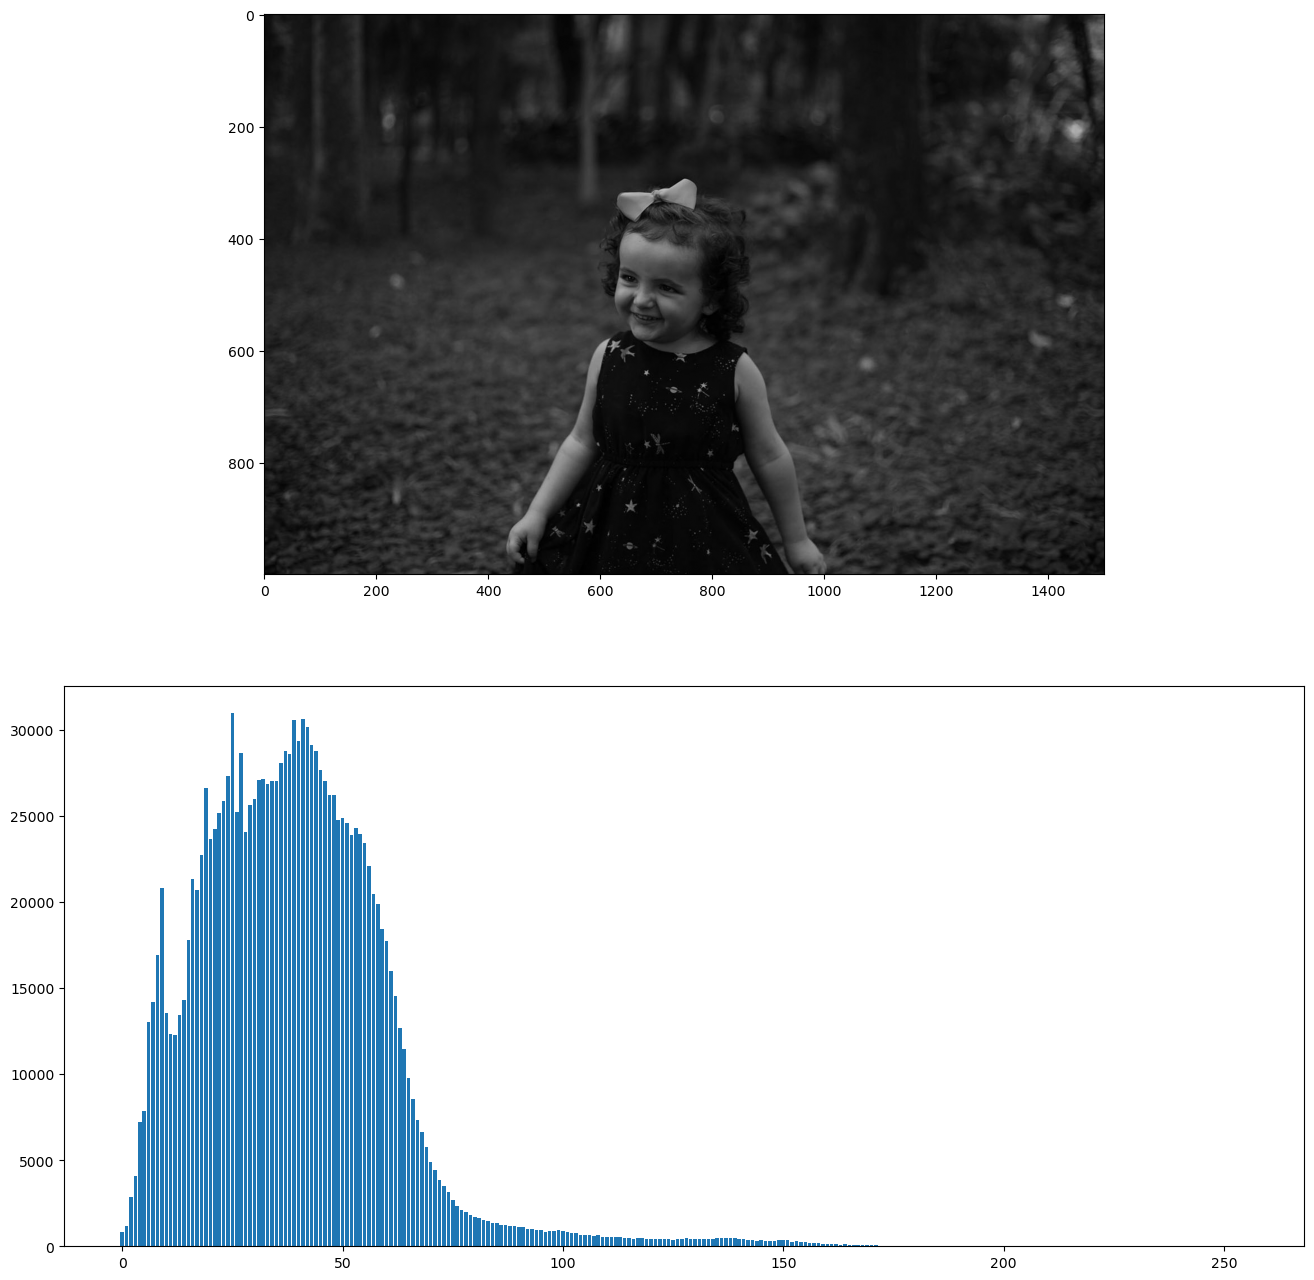

In [13]:
show_histogram_gray(girl_gray)

In [5]:
def show_histogram(img):
    # Para cada canal de cor, calcular o histograma.
    histogram_r = histogram_gray(img[:, :, 0])
    histogram_g = histogram_gray(img[:, :, 1])
    histogram_b = histogram_gray(img[:, :, 2])
    
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram_r, color='red')
    plt.bar(range(256), histogram_g, color='green')
    plt.bar(range(256), histogram_b, color='blue')

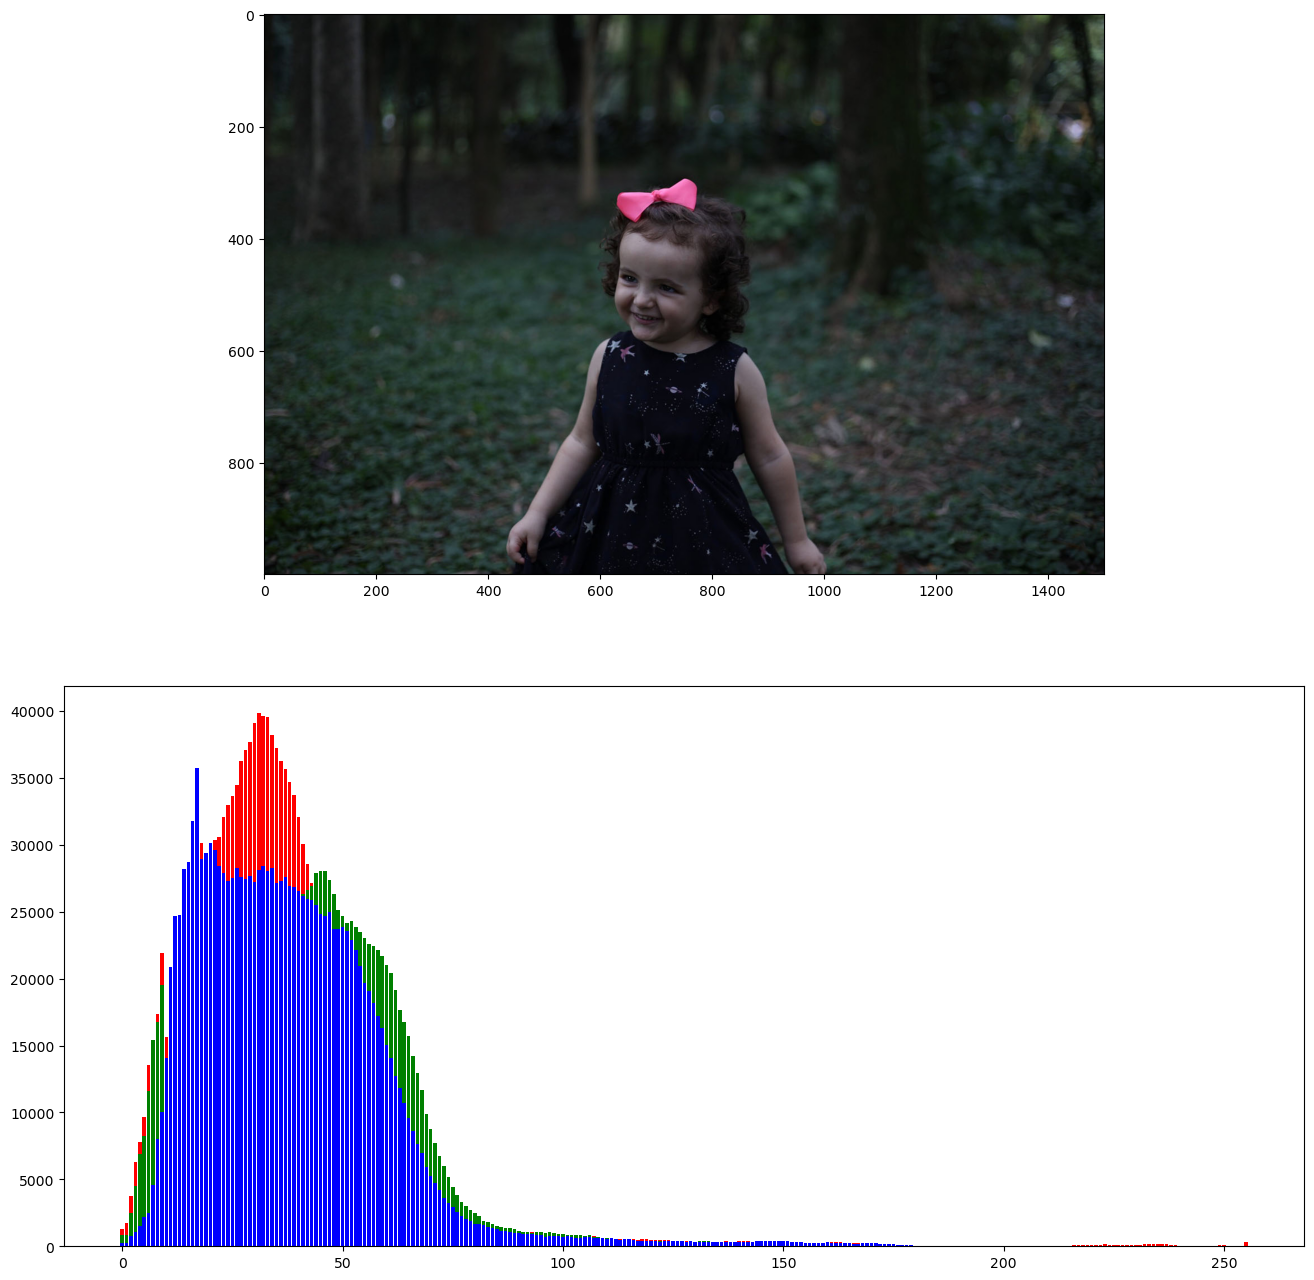

In [6]:
show_histogram(girl)

### Exemplos (iluminação)

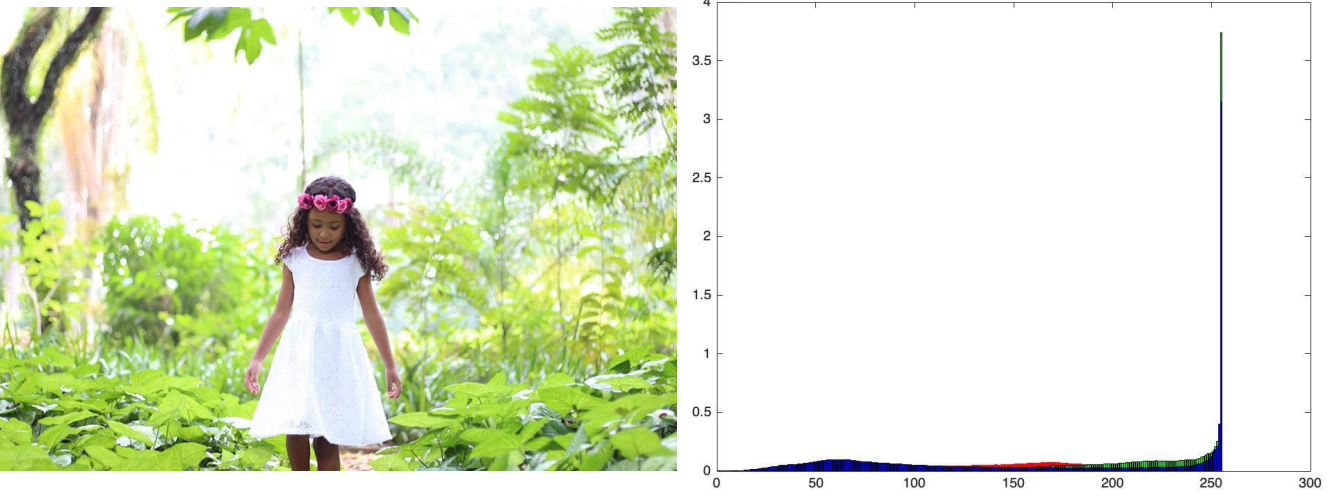

### Exemplos (constraste)

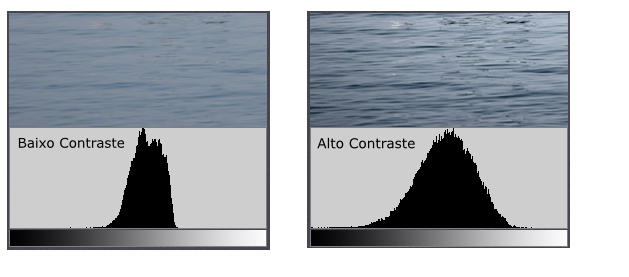

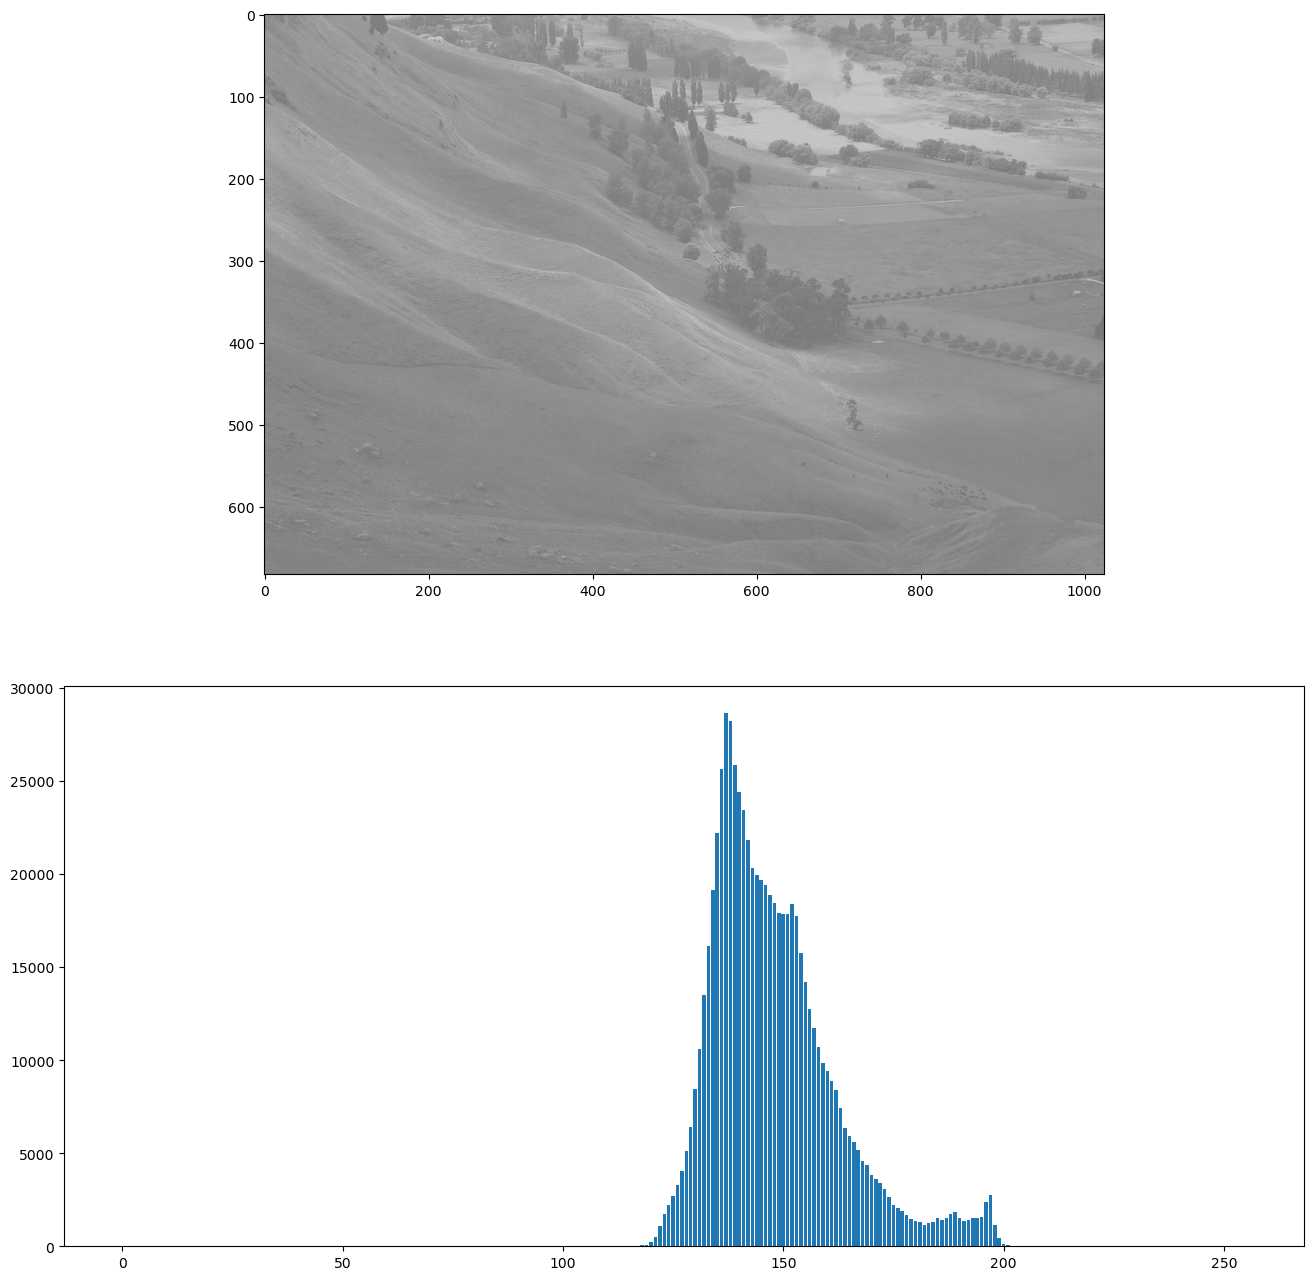

In [7]:
hill = np.array(Image.open('hill.jpg'))
show_histogram_gray(hill)

### Exemplos (saturação)

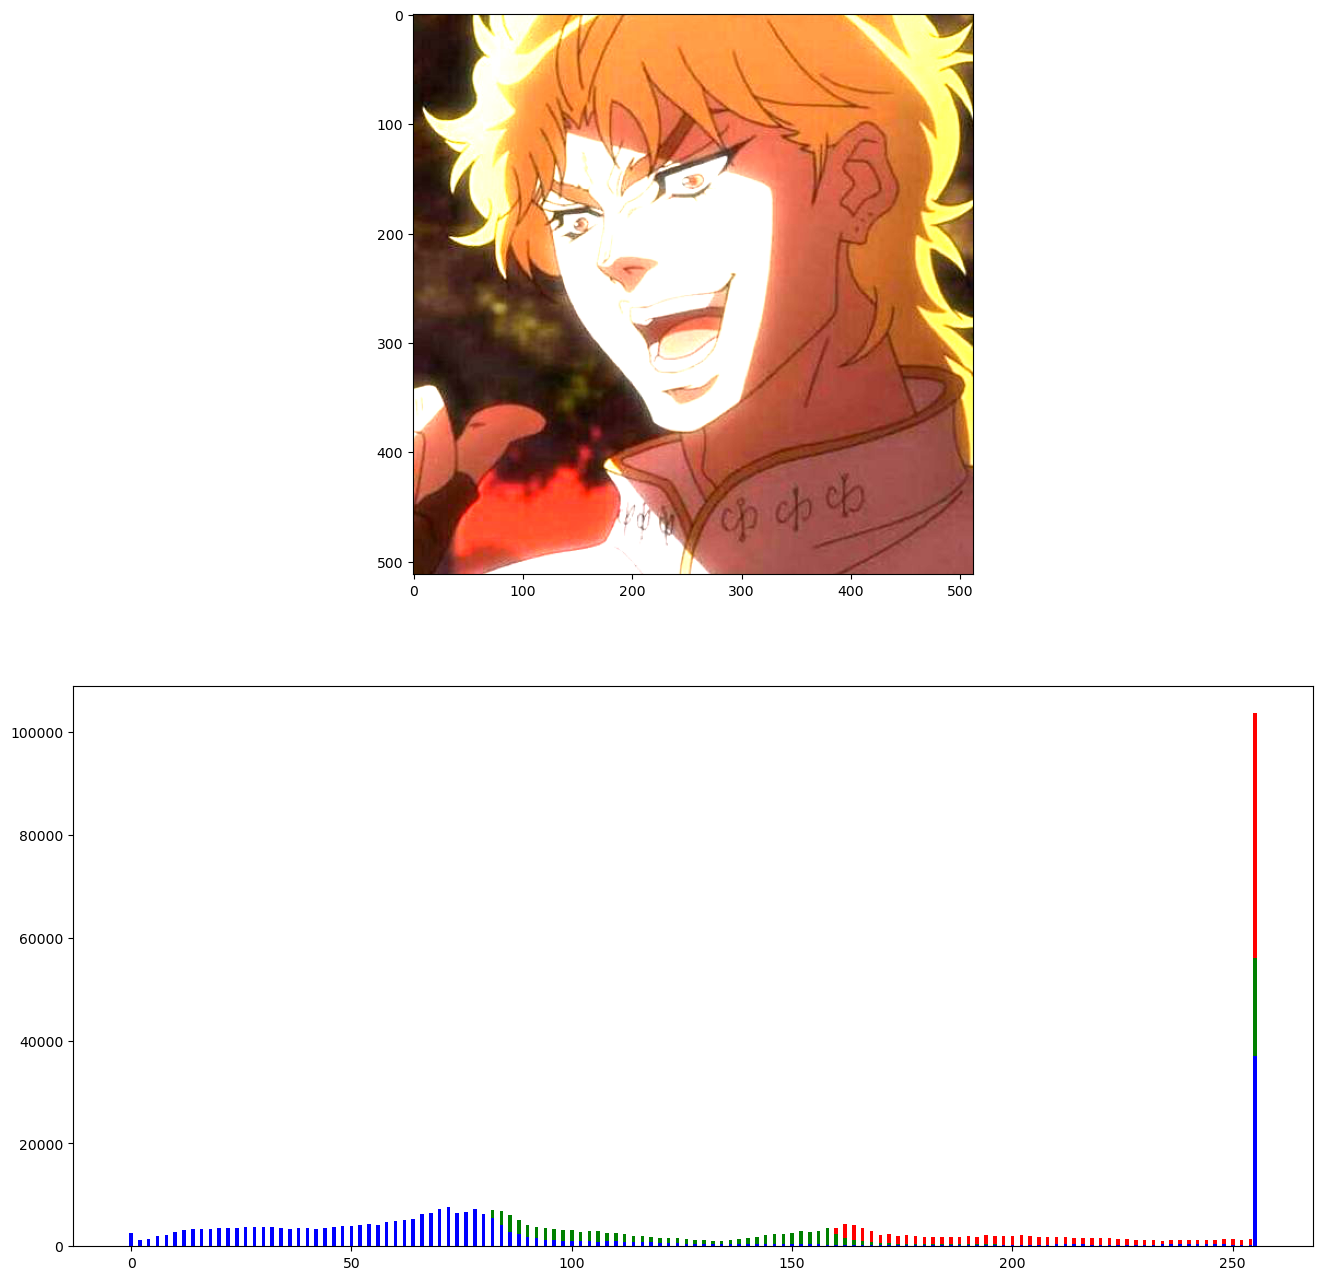

In [8]:
dio = np.array(Image.open('dio_satured.png'))
show_histogram(dio)

### Exemplos (thresholding)

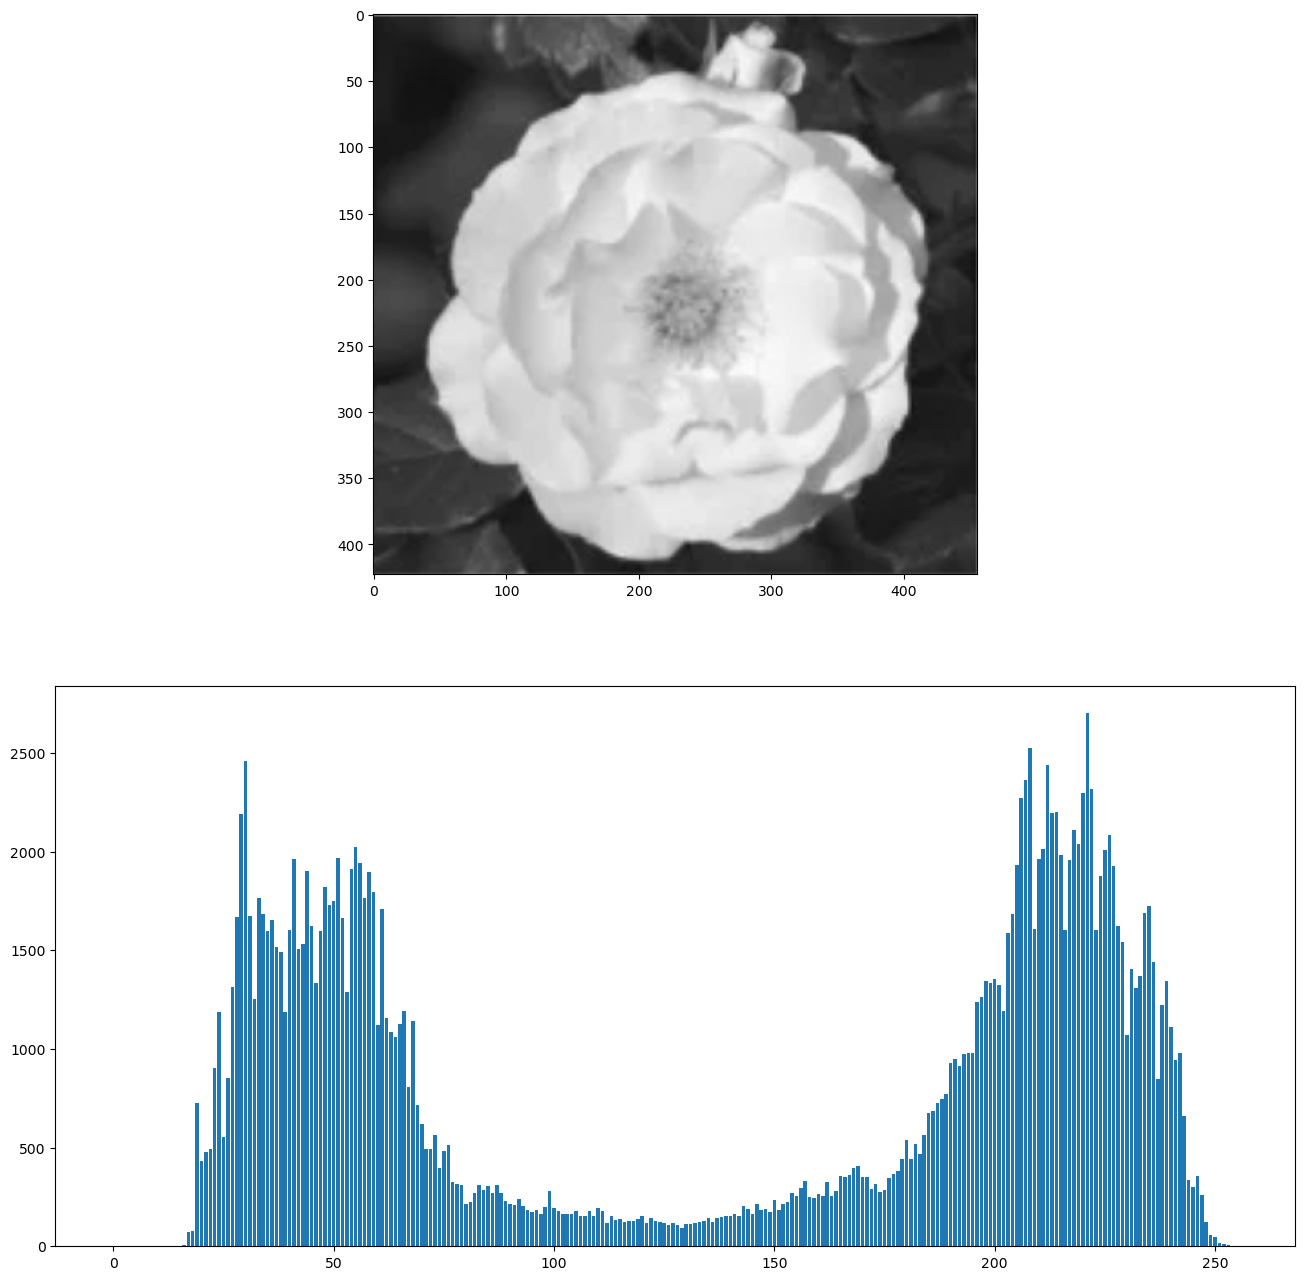

In [9]:
flower = np.array(Image.open('flower.png'))
show_histogram_gray(flower)

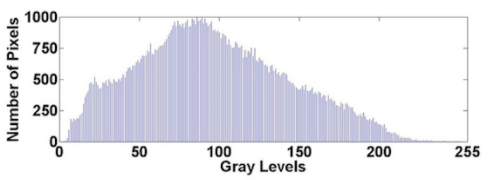

### Limitação
* Um histograma não fornece informação sobre a distribuição espacial dos pixels da imagem;
* Imagens diferentes podem compartilhar o mesmo histograma;
* Sendo assim, não é possível reconstruir imagens a partir de seu histograma.

|a|b|c|
|-|-|-|
|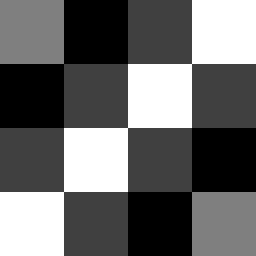|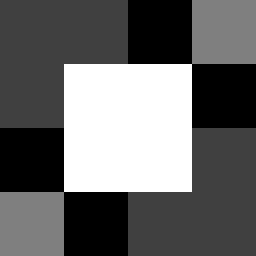|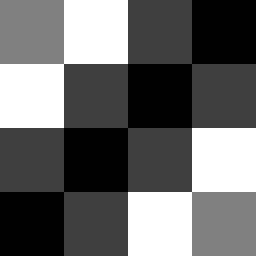|

## Equalização
* É uma técnica para ajustar o contraste (escala entre os tons mais luminosos e escuros);
* Quanto menor o contraste, mais fundidas são as cores; quando maior o contraste, mais marcadas são as cores;
* A equalização permite fazer uma melhor distribuição do contraste, ajustando o histograma da imagem;
* Existem várias fórmulas de equalização, não havendo uma "melhor" para todas as situações.

|Original|Equalizada|
|-|-|
|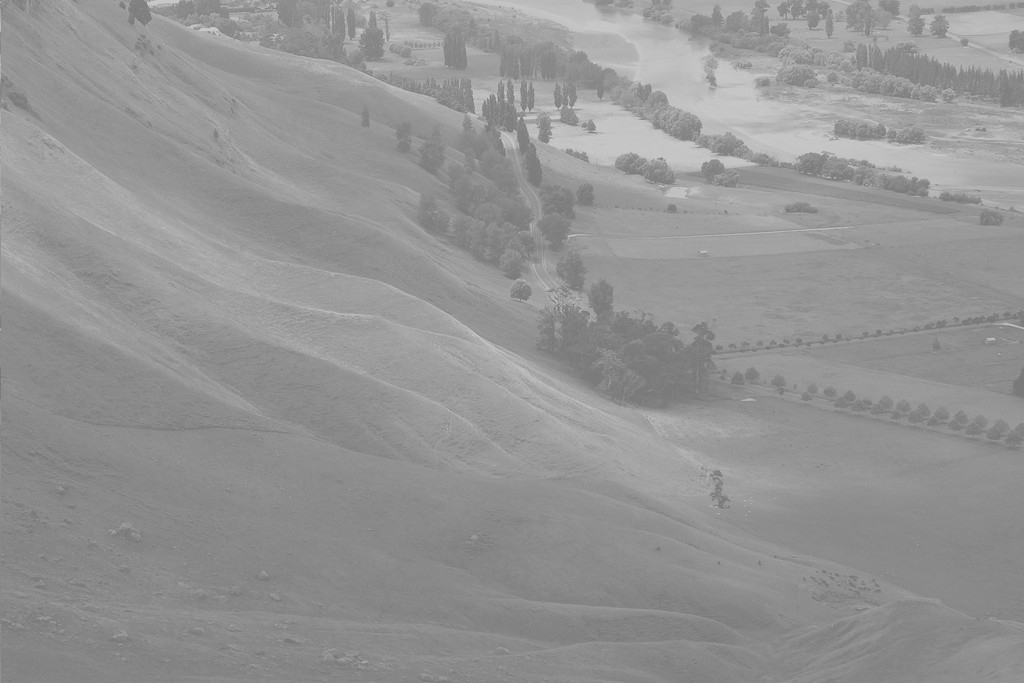|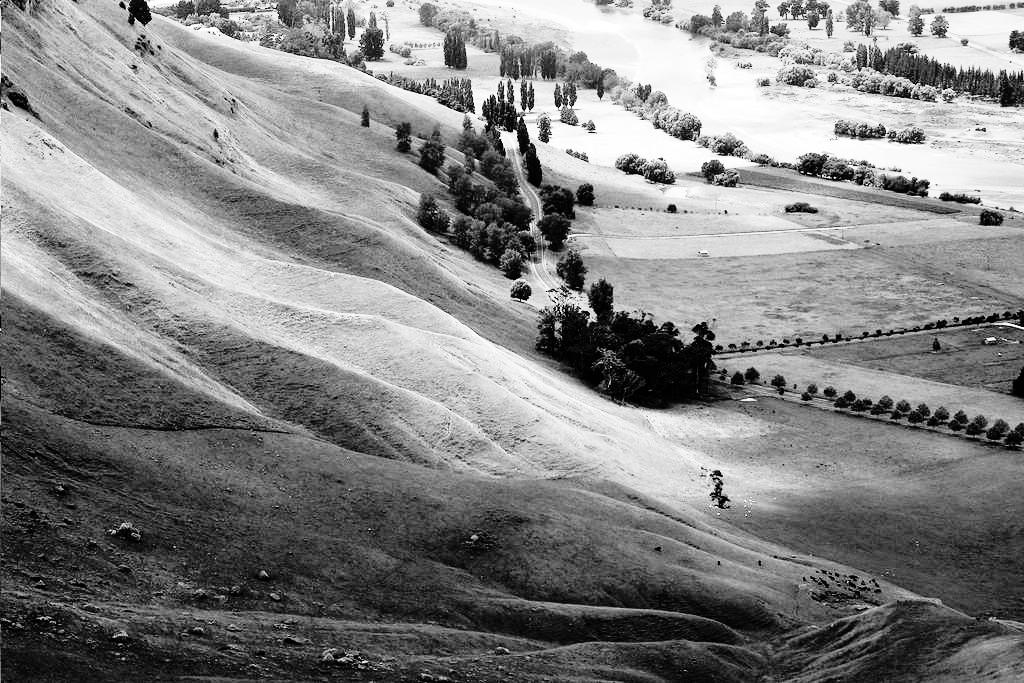|

### Técnica 1
$$h(v) = round\left(\frac{fdc(v) - fdc_{min}}{(M \times N) - fdc_{min}} \times (L - 1)\right)$$
* $h(v)$: novo valor de intensidade para $v$;
* $v$: valor de intensidade original;
* $fdc$: função densidade cumulativa (histograma cumulativo);
* $fdc_{min}$: valor mínimo da $fdc$;
* $L$: número de intensidades de pixel (normalmente 256):
* $M, N$: dimensões da imagem (largura e altura).

Ou, em Python:
```python
# percorrendo cada pixel da imagem:
novo_valor_de_pixel = np.round((fdc[intensidade] - np.min(fdc)) / ((l * c) - np.min(fdc)) * 255)
```

### Técnica 2
$$g_{i,j} = \left\lfloor(L-1)\sum_{n=0}^{f_{i,j}}p_{n}\right\rfloor$$

$$p_{n} = \frac{\text{número de pixels com intensidade n}}{\text{número total de pixels}} \quad n=0,1,\dots,L-1$$
* $f_{i,j}$: valor de intensidade para o pixel em $i,j$;
* $g_{i,j}$: novo valor de intensidade para o pixel em $i,j$;
* $L$: nuḿero de intensidades de pixel (normalmente 256);
* $p_{n}$: frequência relativa da intensidade $n$.

Ou, em Python:
```python
# percorrendo cada pixel da imagem:
novo_valor_de_pixel = np.floor(255 * fdc_normalizada[intensidade])
```

### Histograma cumulativo
Função densidade cumulativa:
$$H(i) = \sum_{j=0}^{i} h(j) \quad 0 \leq i < K$$

* $H(i)$: somatório de todas as frequências de intensidades até $i$;
* $h(j)$: frequência da intensidade $j$;
* $K$: número de intensidades do pixel (normalmente 256).

|Histograma original|Histograma cumulativo original|
|-|-|
|||
|**Histograma equalizado original**|**Histograma cumulativo equalizado**|
|||

# Exercícios

1. Escolha uma imagem colorida na internet e exiba os seguintes histogramas, utilizando `plt.subplot(2, 1, x)`:
  * Dos três canais (**<font color="red">R</font>**, **<font color="green">G</font>** e **<font color="blue">B</font>**) **na mesma janela** (isto é, todas em `x = 1`);
  * Em escala de cinza utilizando um dos três métodos vistos em aulas anteriores (em `x = 2`).

Lembrando:
* **Lightness**: $$\frac{max(r, g, b) + min(r, g, b))}{2}$$
* **Average**: $$\frac{r + g + b}{3}$$
* **Luminosity**: $$0.2126 \times r + 0.7152 \times g + 0.0722 \times b$$

C:\Users\aliss\AppData\Local\Temp\ipykernel_28664\1243745302.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


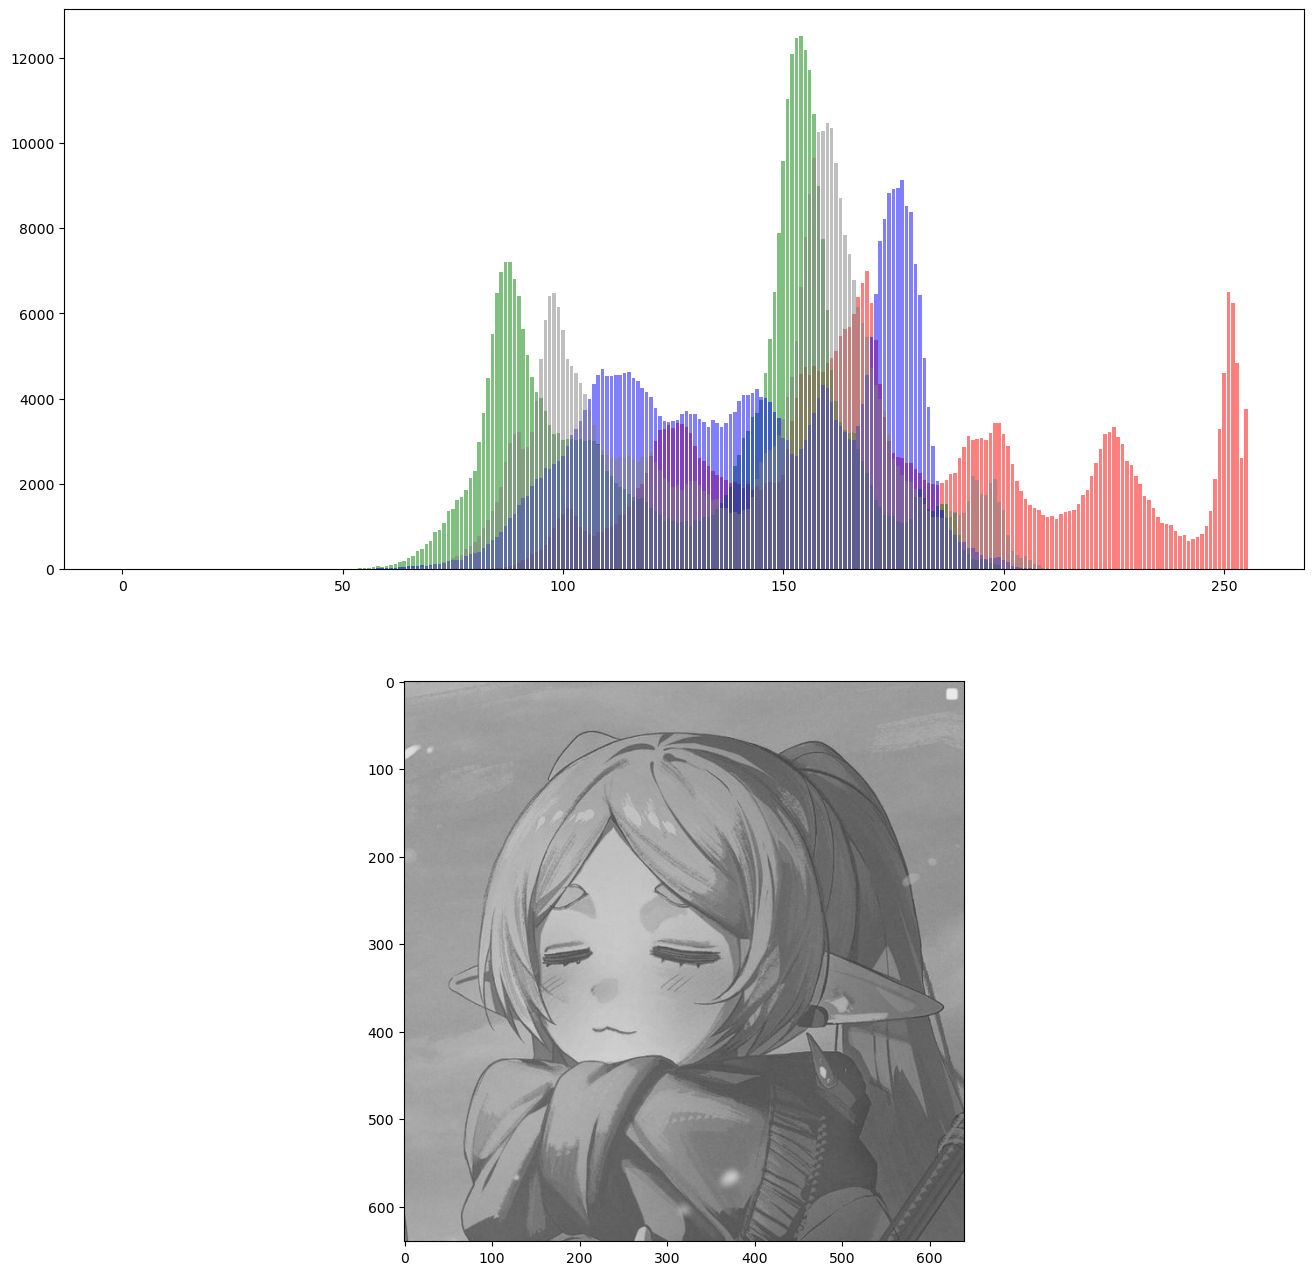

In [10]:
imagem = np.array(Image.open('frieren_sol.jpg'))
l, c, p = imagem.shape

# Função para exibir histogramas de RGB + escala de cinza
def show_histogram_rgb_gray(img):
    histogram_r = histogram_gray(img[:, :, 0])
    histogram_g = histogram_gray(img[:, :, 1])
    histogram_b = histogram_gray(img[:, :, 2])
    
    # Converter para escala de cinza
    img_gray = ((0.2126 * img[:, :, 0]) + (0.7152 * img[:, :, 1]) + (0.0722 * img[:, :, 2])).astype(np.uint8)
    histogram_gray_img = histogram_gray(img_gray)
    
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.bar(range(256), histogram_r, color='red', alpha=0.5, label='Red')
    plt.bar(range(256), histogram_g, color='green', alpha=0.5, label='Green')
    plt.bar(range(256), histogram_b, color='blue', alpha=0.5, label='Blue')
    plt.bar(range(256), histogram_gray_img, color='gray', alpha=0.5, label='Gray')    
    
    plt.subplot(2, 1, 2)
    plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    plt.legend()

show_histogram_rgb_gray(imagem)



2. Escolha uma imagem em grayscale, de preferência com baixo contraste, e aplique nela uma das duas abordagens de equalização.

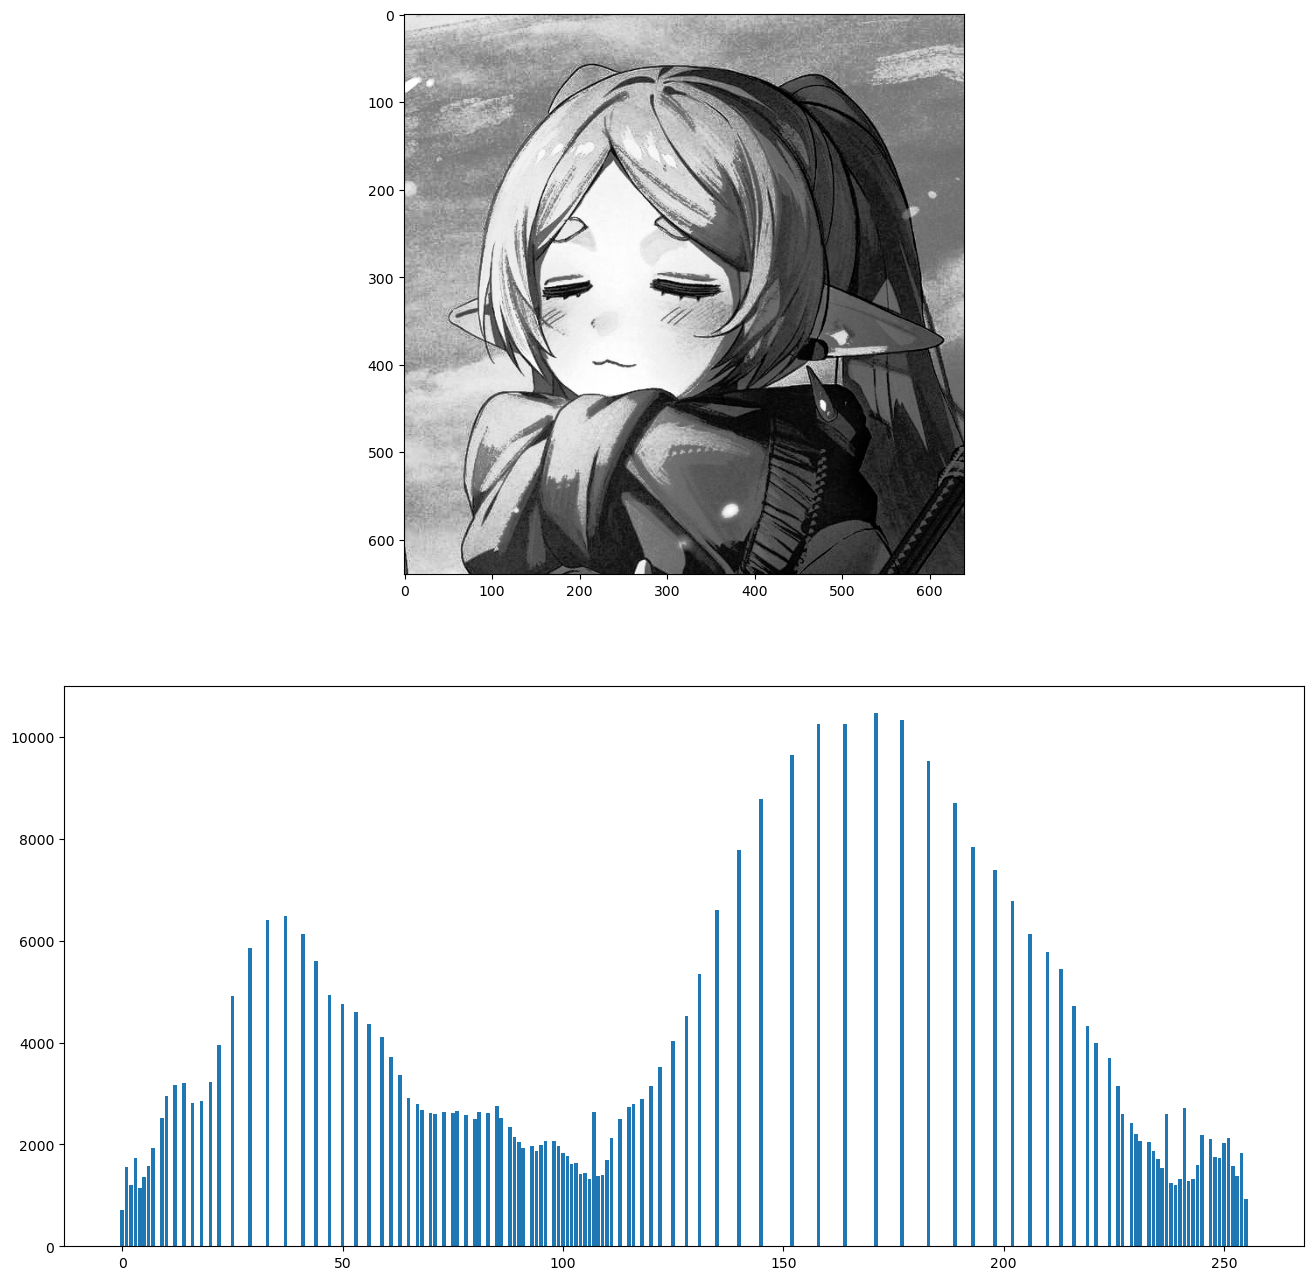

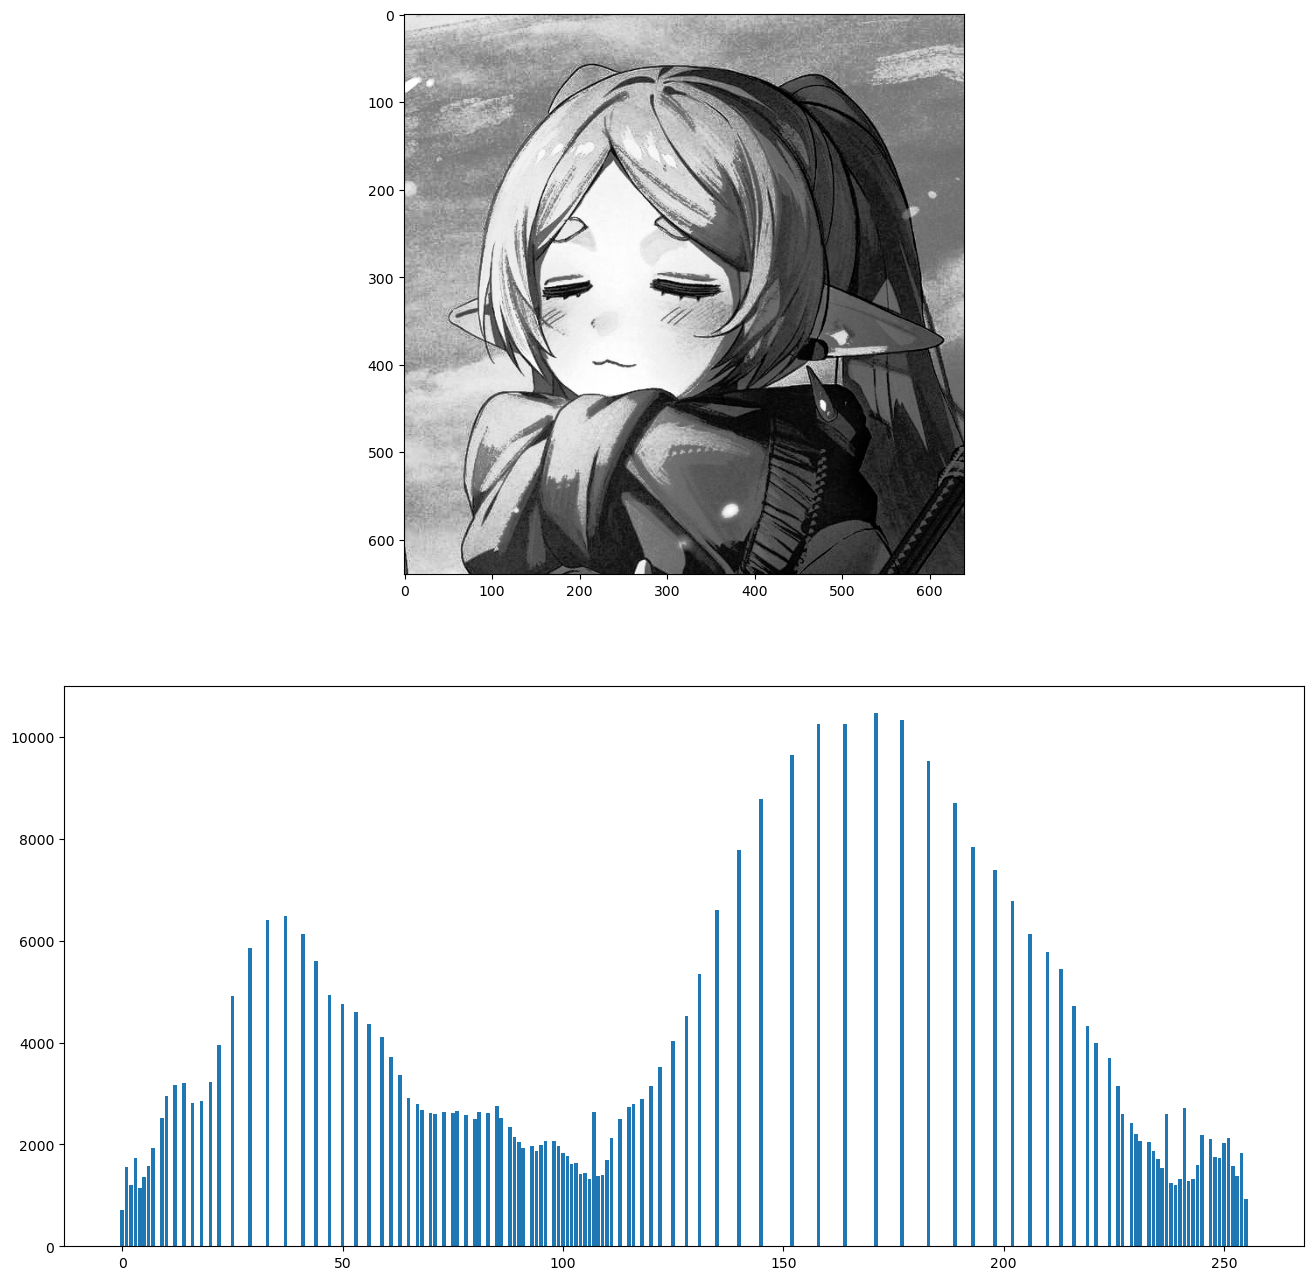

In [11]:
# Equalização usando a técnica 1 na imagem_gray (frieren)
def equalize_histogram(img):
    histogram = histogram_gray(img)
    fdc = np.cumsum(histogram) # FDC é a soma cumulativa do histograma
    intensidade = np.arange(256) # Intensidades de 0 a 255
    novo_valor_de_pixel = np.round((fdc[intensidade] - np.min(fdc)) / ((l * c) - np.min(fdc)) * 255)
    # Criar uma nova imagem equalizada
    img_equalized = np.zeros_like(img) 
    
    for i in range(l):
        for j in range(c):
            intensity = img[i, j]
            img_equalized[i, j] = novo_valor_de_pixel[intensity] # Substituir a intensidade do pixel pela intensidade equalizada
    
    return img_equalized.astype(np.uint8)

imagem_gray = ((0.2126 * imagem[:, :, 0]) + (0.7152 * imagem[:, :, 1]) + (0.0722 * imagem[:, :, 2])).astype(np.uint8)
img_equalized = equalize_histogram(imagem_gray)
show_histogram_gray(img_equalized)

# Equalização usando a técnica 2 na imagem_gray (frieren em grayscale)
def equalize_histogram_technique_2(img):
# Usando a fórmula de equalização de histograma: gij = (L - 1) * somatorio(n=0 até fij) de Pn
# onde gij é a nova intensidade do pixel na posição (i, j) da imagem equalizada
# Onde Pn é número de pixels com intensidade n dividido pelo número total de pixels (l * c)
# Onde Fij é a intensidade do pixel na posição (i, j) da imagem original
    total_pixels = l * c
    Pn = histogram_gray(img) / total_pixels # Probabilidade de cada intensidade
    Fij = np.zeros_like(img)
    fdc_normalizada = np.cumsum(Pn) # FDC normalizada é a soma cumulativa das probabilidades
    

    for i in range(l):
        for j in range(c):
            intensidade = img[i, j]
            Fij[i, j] = np.floor(255 * fdc_normalizada[intensidade])

    return img_equalized

imagem_equalizada2 = equalize_histogram_technique_2(imagem_gray)
show_histogram_gray(imagem_equalizada2)



# Referências:
* https://www.infopedia.pt/$contraste-(fotografia)
* https://en.wikipedia.org/wiki/Contrast_(vision)
* https://www.allaboutcircuits.com/technical-articles/image-histogram-characteristics-machine-learning-image-processing/
* https://en.wikipedia.org/wiki/Histogram_equalization
* https://www.math.uci.edu/icamp/courses/math77c/demos/hist_eq.pdf

Aula remota, conforme Port. 345/2020 – MEC